In [46]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import models, optimizers, regularizers
import matplotlib.pyplot as plt
from keras.models import clone_model

In [36]:
model = models.Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

d:\USUARIO\Desktop\Pc\Estudio\Data\Auto\Data Science\Deep learning\GITHUB\CNN\env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
train_datagen= ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [38]:
test_datagenn = ImageDataGenerator(rescale=1./255)

In [39]:
train_generator = train_datagen.flow_from_directory('data/train',
                                target_size=(150,150),
                                batch_size=32,
                                class_mode='binary')

validation_generator = test_datagenn.flow_from_directory('data/validation',
                                target_size=(150,150),
                                batch_size=32,
                                class_mode='binary')

test_generator = test_datagenn.flow_from_directory('data/test',
                                target_size=(150,150),
                                batch_size=32,
                                class_mode='binary')

Found 2000 images belonging to 2 classes.


Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [40]:
checkpoint = ModelCheckpoint('model_cat_dogs.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [41]:
model.compile(loss='binary_crossentropy', optimizer=optimizers.Adam(), metrics=['accuracy'])

In [42]:
# steps_per_epoch = datos a entrenar, y batch_size (lo de train_generator)
hist = model.fit(train_generator, steps_per_epoch=2000//32, epochs=100, validation_data=validation_generator, validation_steps=1000//32, callbacks=[checkpoint])

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.4970 - loss: 0.7214
Epoch 1: val_accuracy improved from -inf to 0.50504, saving model to model_cat_dogs.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 659ms/step - accuracy: 0.4971 - loss: 0.7211 - val_accuracy: 0.5050 - val_loss: 0.6928
Epoch 2/100
 1/62 ━━━━━━━━━━━━━━━━━━━━ 30s 495ms/step - accuracy: 0.5000 - loss: 0.6923
Epoch 2: val_accuracy did not improve from 0.50504
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5000 - loss: 0.6923 - val_accuracy: 0.3750 - val_loss: 0.6926
Epoch 3/100


C:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.5107 - loss: 0.6936
Epoch 3: val_accuracy did not improve from 0.50504
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 605ms/step - accuracy: 0.5105 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 4/100
 1/62 ━━━━━━━━━━━━━━━━━━━━ 27s 446ms/step - accuracy: 0.5312 - loss: 0.6917
Epoch 4: val_accuracy did not improve from 0.50504
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.5312 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6895
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.5095 - loss: 0.6924
Epoch 5: val_accuracy improved from 0.50504 to 0.61996, saving model to model_cat_dogs.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 36s 587ms/step - accuracy: 0.5095 - loss: 0.6924 - val_accuracy: 0.6200 - val_loss: 0.6925
Epoch 6/100
 1/62 ━━━━━━━━━━━━━━━━━━━━ 30s 507ms/step - accuracy: 0.5000 - loss: 0.6928
Epoch 6: val_accuracy improved from 0.61996 to 0.62500, saving model to model_cat_dogs.keras
62/62 ━━━━━━━━━━━━━━━

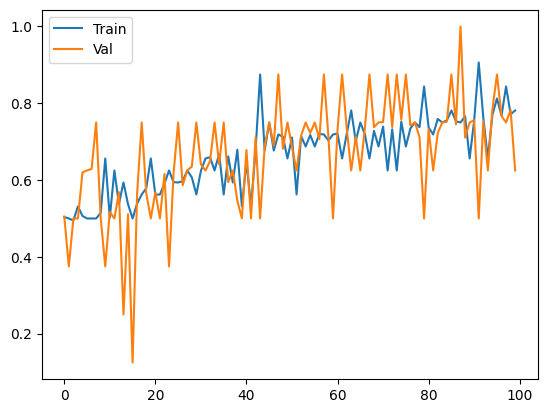

In [43]:
plt.plot(hist.history['accuracy'],label = 'Train')
plt.plot(hist.history['val_accuracy'],label = 'Val')
plt.legend()
plt.show()

In [44]:
model2 = clone_model(model)
model2.load_weights('model_cat_dogs.keras')

optimizers.Adam()

In [45]:
model2.compile(optimizer=optimizers.Adam(),
            loss='binary_crossentropy',
            metrics=['accuracy'])
model2.evaluate(test_generator)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - accuracy: 0.7306 - loss: 0.6053


[0.5880956053733826, 0.7329999804496765]